In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline

In [6]:
df = pd.read_csv(r"C:\Users\deepa\OneDrive\Desktop\Loan Approval Prediction Project\Loan_Approval_Dataset.csv")
df.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


In [7]:
df.shape

(4269, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [9]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [10]:
df.isnull().sum()
# There is no NULL values in any of the columns of the dataset. So No need of Data Cleaning

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [11]:
df.duplicated().sum()

0

# 1. Data Exploration

In [12]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [13]:
df["education"].value_counts(dropna=False)

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [14]:
df["self_employed"].value_counts(dropna=False)

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [15]:
df['loan_status'].value_counts(dropna=False)

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [16]:
countYes = len(df[df.loan_status == "Approved"])
countNo = len(df[df.loan_status == "Rejected"])
total_Loan = len(df.loan_status)

print("Approved loan : {:.2f}%".format((countYes/total_Loan)*100))
print("Rejected Loan : {:.2f}%".format((countNo/total_Loan)*100))

Approved loan : 0.00%
Rejected Loan : 0.00%


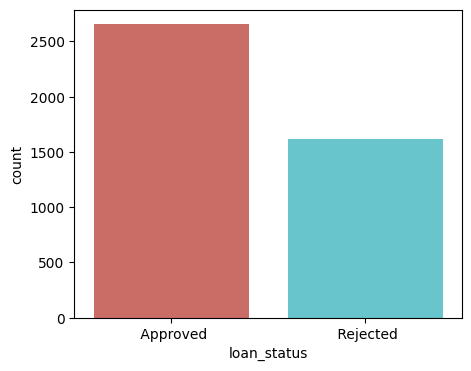

In [17]:
plt.figure(figsize=(5,4))
sns.countplot(data = df , x = "loan_status" , palette = "hls")
plt.show()

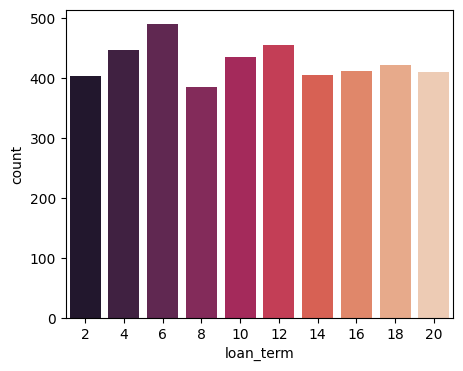

In [18]:
plt.figure(figsize=(5,4))
sns.countplot(data = df , x = "loan_term" , palette = "rocket")
plt.show()



---



# 2. DATA VISUALIZATION

In [19]:
df.head(3)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected


In [20]:
numeric_col = df.select_dtypes(include = np.number)

In [21]:
corr = numeric_col.corr()

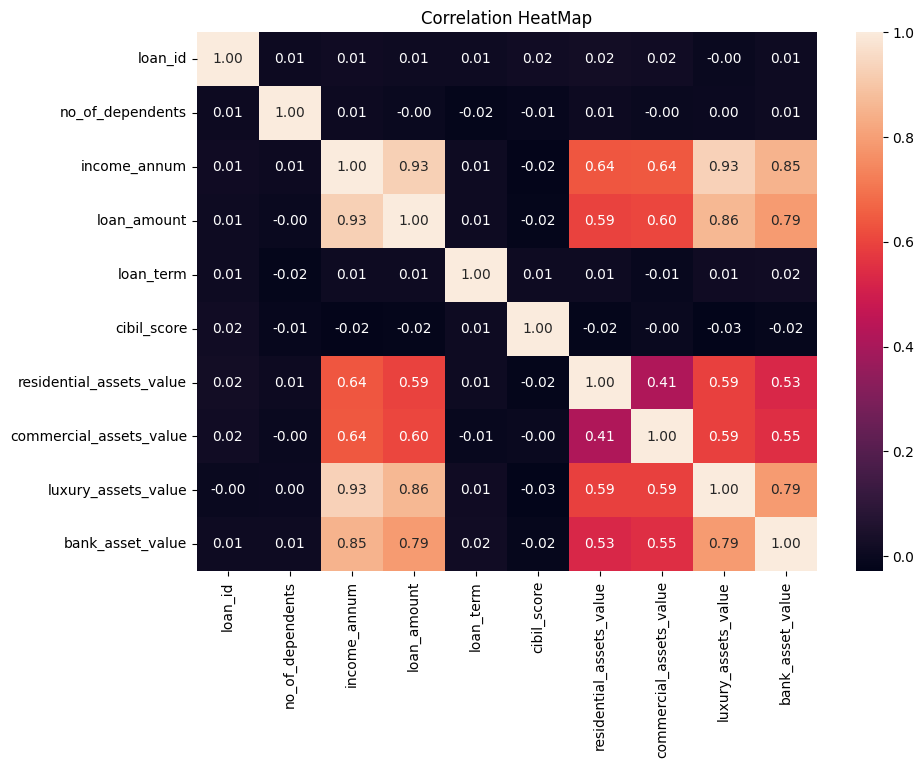

In [22]:
plt.figure(figsize=(10,7))
sns.heatmap(corr , annot = True, fmt = ".2f")
plt.title("Correlation HeatMap")
plt.show()

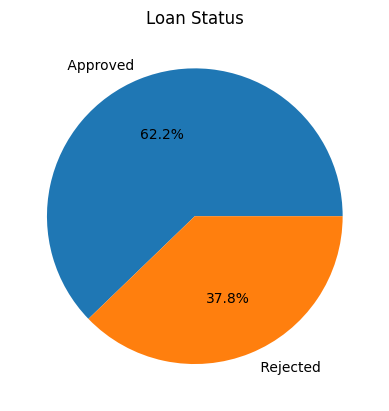

In [23]:
# Loan Status
Loan_Status = df["loan_status"].value_counts()
plt.pie(Loan_Status , labels = Loan_Status.index , autopct = "%1.1f%%")
plt.title("Loan Status")
plt.show()

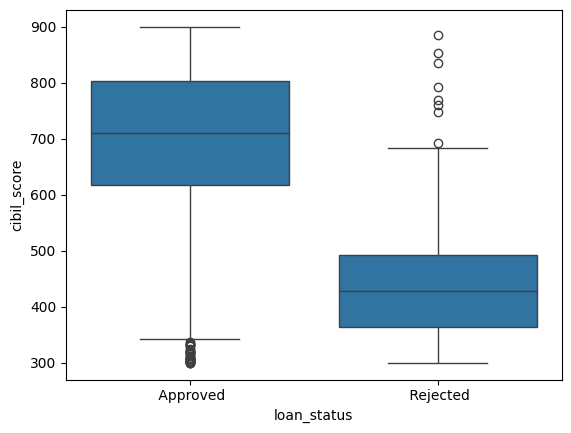

In [24]:
# BOX PLOT
sns.boxplot(data = df , x = "loan_status" , y = "cibil_score")
plt.show()

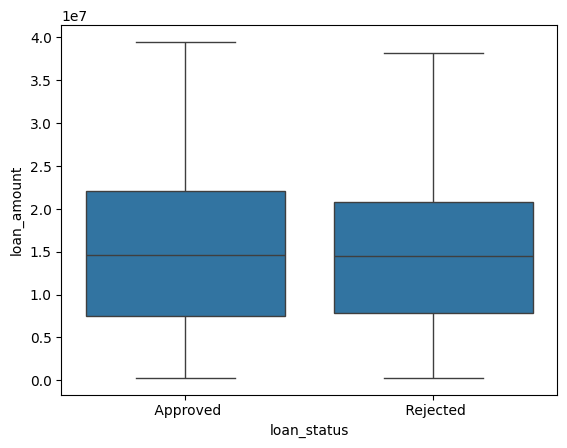

In [25]:
sns.boxplot(data = df, x="loan_status" , y ="loan_amount")
plt.show()

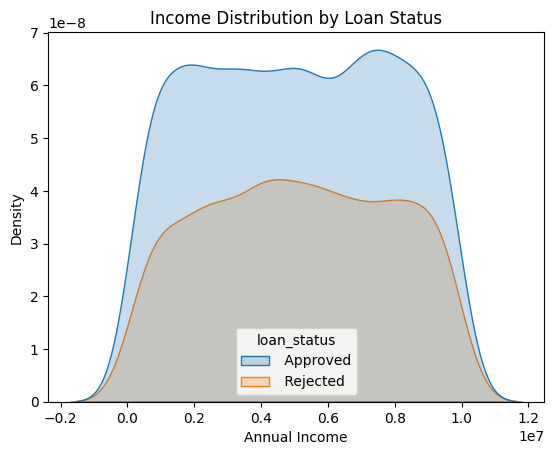

In [26]:

# KDE PLOT
sns.kdeplot(data = df , x = "income_annum" , hue = "loan_status" , fill = True)
plt.xlabel("Annual Income")
plt.title("Income Distribution by Loan Status")
plt.show()

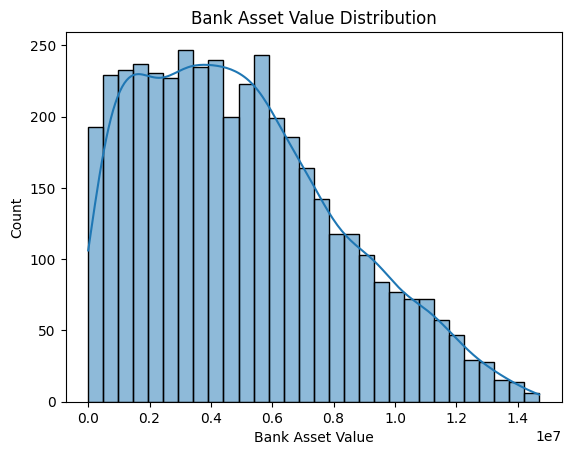

In [27]:
sns.histplot(df["bank_asset_value"], bins=30, kde =True)
plt.title("Bank Asset Value Distribution")
plt.xlabel("Bank Asset Value")
plt.show()

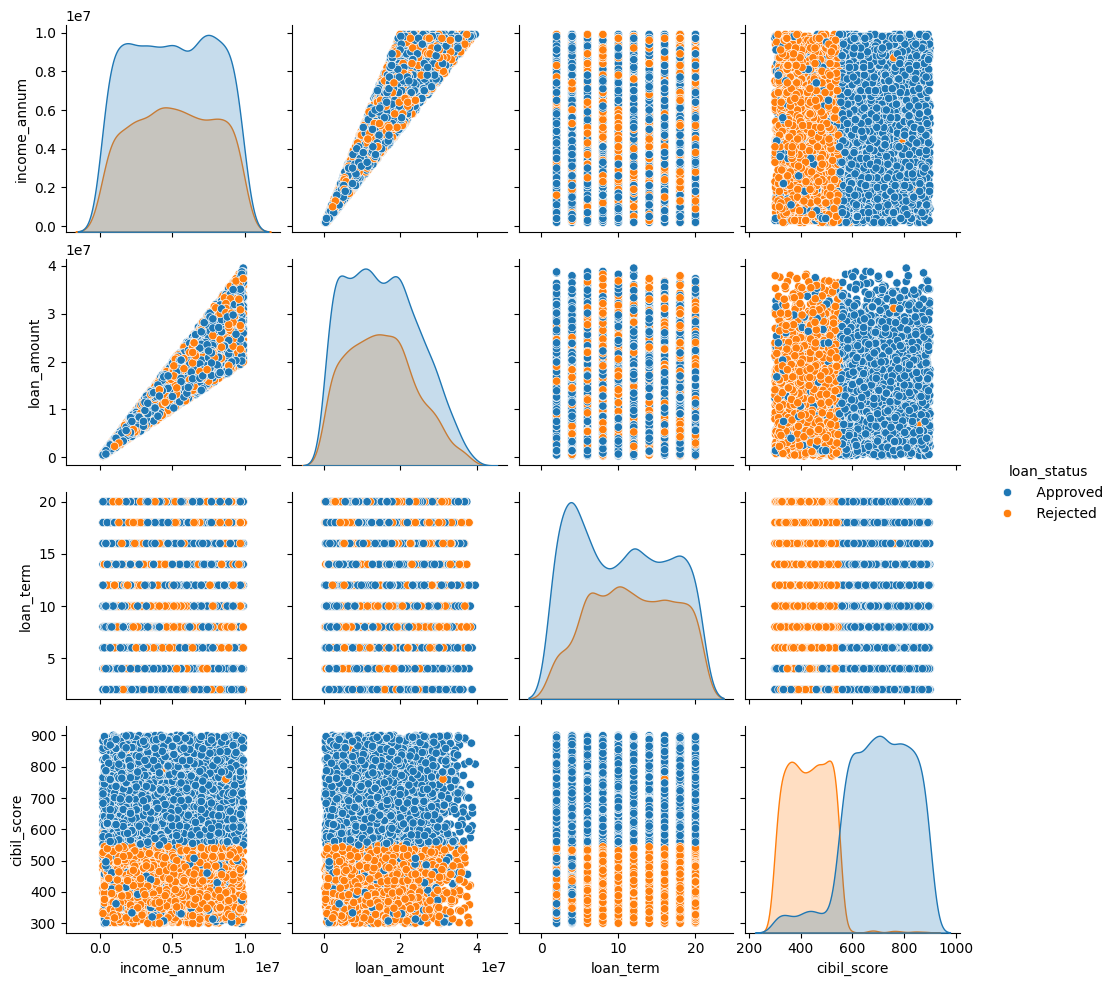

In [28]:
sns.pairplot(df[['income_annum','loan_amount','loan_term','cibil_score','loan_status']],hue="loan_status")
plt.show()

In [29]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected




---



# 3. DATA PREPROCESSING

In [30]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [31]:
# checking missing values
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [32]:
# dropping features that are not needed
df = df.drop(["loan_id","no_of_dependents","education"] , axis=1)
df


,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...
4264,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [33]:
df["loan_status"] = df["loan_status"].astype(str).str.strip()
df["self_employed"] = df["self_employed"].astype(str).str.strip()

In [34]:
df["self_employed"] = df["self_employed"].replace({
    "No": 0,
    "Yes": 1
})

# 2. Now cast the column to the integer type
df["self_employed"] = df["self_employed"].astype(int)

In [35]:
# LABEL ENCODER
from sklearn.preprocessing import LabelEncoder

In [36]:
le_status = LabelEncoder()
df["loan_status"] = le_status.fit_transform(df["loan_status"])

In [37]:
df.select_dtypes(include = np.number).columns

Index(['self_employed', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [38]:
print("Loan Status Mapping:")
print(dict(zip(le_status.classes_, le_status.transform(le_status.classes_))))

Loan Status Mapping:
{'Approved': 0, 'Rejected': 1}


In [39]:
print("Final Loan Status Mapping:", dict(zip(le_status.classes_, le_status.transform(le_status.classes_))))

Final Loan Status Mapping: {'Approved': 0, 'Rejected': 1}




---



# 4. TRAIN TEST SPLIT

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [41]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [42]:
# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [43]:
ss = StandardScaler()
x_train = ss.fit_transform(x_train)
x_test = ss.transform(x_test)



---



# 5. MODEL TRAINING

Model Trained (LR , KNN , SVM , DT , RF , XGBoost)

## 5.1 Logistic Regression

In [44]:
# LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [45]:
y_predict = lr.predict(x_test)

In [46]:
# ACCURACY , CONFUSION MATRIX
from sklearn.metrics import confusion_matrix , accuracy_score , classification_report

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [48]:

print("Classification Report : " , classification_report(y_test,y_predict))
print( confusion_matrix(y_test,y_predict))

Classification Report :                precision    recall  f1-score   support

           0       0.92      0.93      0.92       536
           1       0.88      0.86      0.87       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854

[[498  38]
 [ 43 275]]


In [49]:
lrAcc = accuracy_score(y_predict,y_test)
print("Logistic Regression Accuracy : {:.2f}%".format(lrAcc * 100))

Logistic Regression Accuracy : 90.52%


In [50]:
accuracy = accuracy_score(y_test, y_predict)

# Precision
precision = precision_score(y_test, y_predict)

# Recall
recall = recall_score(y_test, y_predict)

# F1 Score
f1 = f1_score(y_test, y_predict)

print("Accuracy:", accuracy*100)
print("Precision:", precision*100)
print("Recall:", recall*100)
print("F1 Score:", f1*100)

Accuracy: 90.5152224824356
Precision: 87.8594249201278
Recall: 86.47798742138365
F1 Score: 87.16323296354992


## 5.2 KNN

In [51]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knc = KNeighborsClassifier(n_neighbors = 2)
knc.fit(x_train,y_train)

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [52]:
y_predict = knc.predict(x_test)

In [53]:
print("Classification Report : " , classification_report(y_test,y_predict))
print(confusion_matrix(y_test,y_predict))

Classification Report :                precision    recall  f1-score   support

           0       0.86      0.97      0.91       536
           1       0.93      0.74      0.82       318

    accuracy                           0.88       854
   macro avg       0.90      0.85      0.87       854
weighted avg       0.89      0.88      0.88       854

[[519  17]
 [ 84 234]]


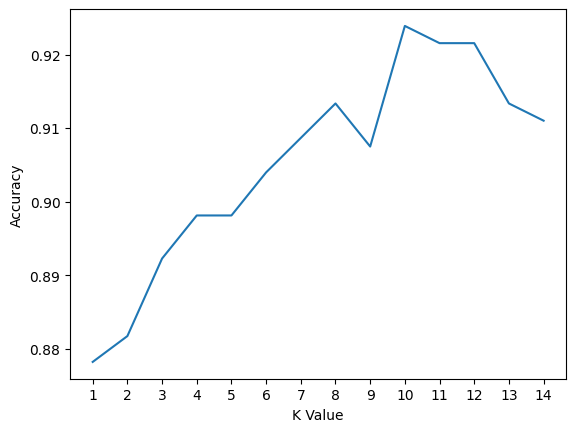

In [54]:
knnScore = []
for i in range(1,15):
  knnClassifier = KNeighborsClassifier(n_neighbors = i)
  knnClassifier.fit(x_train,y_train)
  knnScore.append(knnClassifier.score(x_test,y_test))

plt.plot(range(1,15),knnScore)
plt.xticks(np.arange(1,15,1))
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()

In [55]:
KnnAcc = max(knnScore)
print("KNN Accuracy : {:.2f}%".format(KnnAcc*100))

KNN Accuracy : 92.39%


In [56]:
accuracy = accuracy_score(y_test, y_predict)

# Precision
precision = precision_score(y_test, y_predict)

# Recall
recall = recall_score(y_test, y_predict)

# F1 Score
f1 = f1_score(y_test, y_predict)

print("Accuracy:", accuracy*100)
print("Precision:", precision*100)
print("Recall:", recall*100)
print("F1 Score:", f1*100)

Accuracy: 88.17330210772833
Precision: 93.22709163346613
Recall: 73.58490566037736
F1 Score: 82.24956063268893


## 5.3 DECISION TREE

In [57]:
from sklearn.tree import DecisionTreeClassifier

In [58]:
dt = DecisionTreeClassifier(max_depth=15)
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
y_predict = dt.predict(x_test)

In [60]:

print("Classification Report" , classification_report(y_test,y_predict))
print(confusion_matrix(y_test,y_predict))

Classification Report               precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

[[528   8]
 [ 11 307]]


In [61]:
dtScore = []
for i in range(2,30):
  dtClassifier = DecisionTreeClassifier(max_depth = i)
  dtClassifier.fit(x_train,y_train)
  dtScore.append(dtClassifier.score(x_test,y_test))

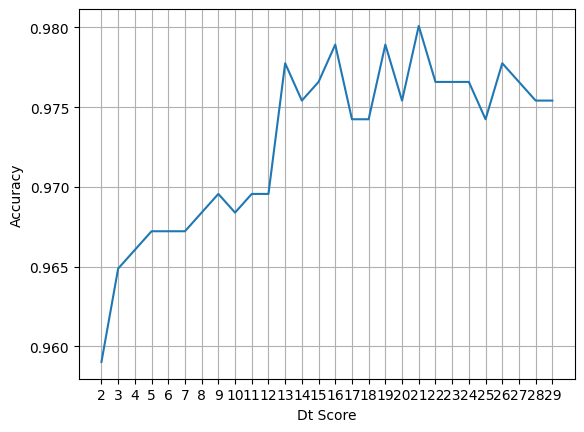

In [62]:
plt.plot(range(2,30),dtScore)
plt.xticks(np.arange(2,30,1))
plt.xlabel("Dt Score")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [63]:
DtAcc = max(dtScore)
print("Decision Tree Accuracy : {:.2f}%".format(DtAcc * 100))

Decision Tree Accuracy : 98.01%


In [64]:
accuracy = accuracy_score(y_test, y_predict)

# Precision
precision = precision_score(y_test, y_predict)

# Recall
recall = recall_score(y_test, y_predict)

# F1 Score
f1 = f1_score(y_test, y_predict)

print("Accuracy:", accuracy*100)
print("Precision:", precision*100)
print("Recall:", recall*100)
print("F1 Score:", f1*100)

Accuracy: 97.7751756440281
Precision: 97.46031746031746
Recall: 96.54088050314465
F1 Score: 96.99842022116904


## 5.4 RANDOM FOREST

In [65]:
from sklearn.ensemble import RandomForestClassifier

In [66]:
rf = RandomForestClassifier( n_estimators=100,max_depth=15, class_weight= 'balanced')
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
y_prd = rf.predict(x_test)
print("Classification report\n " , classification_report(y_test,y_prd))
print(confusion_matrix(y_test,y_prd))

Classification report
                precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854

[[529   7]
 [ 12 306]]


In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score
print("\nClassification Report:\n", classification_report(y_test, y_prd))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_prd))
print("\nAccuracy: {:.2f}%".format(accuracy_score(y_test, y_prd) * 100))


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854


Confusion Matrix:
 [[529   7]
 [ 12 306]]

Accuracy: 97.78%


In [69]:
rfScore = []
for i in range(2,30):
  rfClassifier = RandomForestClassifier(n_estimators = 100 , max_depth = i)
  rfClassifier.fit(x_train,y_train)
  rfScore.append(rfClassifier.score(x_test,y_test))

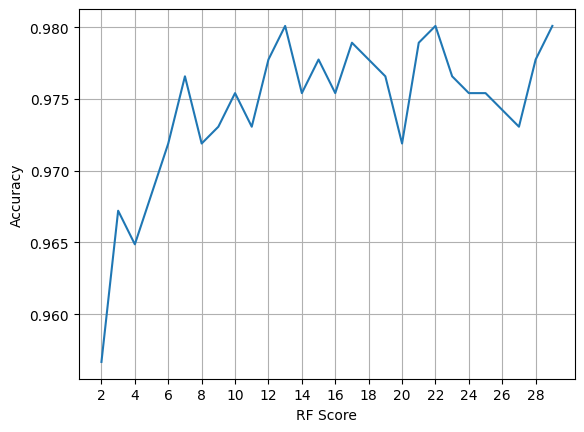

In [70]:
plt.plot(range(2,30),rfScore)
plt.xticks(np.arange(2,30,2))
plt.xlabel("RF Score")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [71]:
RfAcc = max(rfScore)
print("Random Forest Accuracy : {:.2f}%".format(RfAcc * 100))

Random Forest Accuracy : 98.01%


In [72]:
print("Classification Report\n", classification_report(y_test, y_prd))
print(confusion_matrix(y_test, y_prd))

Classification Report
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854

[[529   7]
 [ 12 306]]


In [73]:
accuracy = accuracy_score(y_test, y_predict)

# Precision
precision = precision_score(y_test, y_predict)

# Recall
recall = recall_score(y_test, y_predict)

# F1 Score
f1 = f1_score(y_test, y_predict)

print("Accuracy:", accuracy*100)
print("Precision:", precision*100)
print("Recall:", recall*100)
print("F1 Score:", f1*100)

Accuracy: 97.7751756440281
Precision: 97.46031746031746
Recall: 96.54088050314465
F1 Score: 96.99842022116904


## 5.5 SVM

In [74]:
from sklearn.svm import SVC

In [75]:
sv = SVC()
sv.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [76]:
y_predict = sv.predict(x_test)
print("Classification Report : " , classification_report(y_test,y_predict))
print(confusion_matrix(y_test,y_predict))

Classification Report :                precision    recall  f1-score   support

           0       0.95      0.94      0.94       536
           1       0.90      0.92      0.91       318

    accuracy                           0.93       854
   macro avg       0.92      0.93      0.93       854
weighted avg       0.93      0.93      0.93       854

[[502  34]
 [ 25 293]]


In [77]:
SvAcc = accuracy_score(y_predict,y_test)
print("SVC Accuracy : {:.2f}%".format(SvAcc*100))

SVC Accuracy : 93.09%


In [78]:
accuracy = accuracy_score(y_test, y_predict)

# Precision
precision = precision_score(y_test, y_predict)

# Recall
recall = recall_score(y_test, y_predict)

# F1 Score
f1 = f1_score(y_test, y_predict)

print("Accuracy:", accuracy*100)
print("Precision:", precision*100)
print("Recall:", recall*100)
print("F1 Score:", f1*100)

Accuracy: 93.09133489461358
Precision: 89.60244648318043
Recall: 92.13836477987421
F1 Score: 90.85271317829458


## 5.6 XgBoost

In [80]:
!pip install xgboost
from xgboost import XGBClassifier

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 217.9 kB/s eta 0:07:47
   ---------------------------------------- 0.1/101.7 MB 465.5 kB/s eta 0:03:39
   ---------------------------------------- 0.3/101.7 MB 1.9 MB/s eta 0:00:54
   ---------------------------------------- 0.6/101.7 MB 3.4 MB/s eta 0:00:30
   ---------------------------------------- 1.1/101.7 MB 4.7 MB/s eta 0:00:22
    --------------------------------------- 1.5/101.7 MB 5.6 MB/s eta 0:00:18
    --------------------------------------- 2.0/101.7 MB 6.2 MB/s eta 0:00:17
    --------------------------------------- 2.5/101.7 MB 6.8 MB/s eta 0:00:15
   - -------------------------------------- 2.8/101.7 MB 7.0 MB/s eta 0:00:15
   - -------------------------------------- 3.3/101.7 MB 7.3 MB/s eta 0:00:14
   - -------------------------------------- 3.7/101.7 MB 7.5 MB/s eta 0:00


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [81]:
xgb = XGBClassifier()
xgb.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [82]:
y_predict = xgb.predict(x_test)
XgBAcc = accuracy_score(y_predict,y_test)
print("xgbBoost Accuracy : {:.2f}%".format(XgBAcc*100))

xgbBoost Accuracy : 97.89%


In [83]:
print("Classification Report:", classification_report(y_test, y_predict))
print(confusion_matrix(y_test,y_predict))

Classification Report:               precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

[[528   8]
 [ 10 308]]


In [84]:
accuracy = accuracy_score(y_test, y_predict)

# Precision
precision = precision_score(y_test, y_predict)

# Recall
recall = recall_score(y_test, y_predict)

# F1 Score
f1 = f1_score(y_test, y_predict)

print("Accuracy:", accuracy*100)
print("Precision:", precision*100)
print("Recall:", recall*100)
print("F1 Score:", f1*100)

Accuracy: 97.89227166276346
Precision: 97.46835443037975
Recall: 96.85534591194968
F1 Score: 97.16088328075709




---



# 6. Model Comparison

In [85]:
pd.DataFrame({"Model"  : ['Logistic Regression' , 'k Neighbors Classifier' , 'Decision Tree Classifier' , 'Random Forest' , 'SVM Classifier' , 'XgBoost Classifier'] ,
              "Accuracy" : [lrAcc*100 , KnnAcc*100 , DtAcc*100  , RfAcc*100 , SvAcc*100 , XgBAcc*100]}).sort_values(by = "Accuracy" , ascending=False)

,Model,Accuracy
2,Decision Tree Classifier,98.009368
3,Random Forest,98.009368
5,XgBoost Classifier,97.892272
4,SVM Classifier,93.091335
1,k Neighbors Classifier,92.388759
0,Logistic Regression,90.515222


In [86]:

# Model Comparison Visualization
models = ['Logistic' , 'KNN' , 'Decision Tree' , 'Random Forest' , 'SVM' , 'XgBoost']
accuracy = [lrAcc*100,KnnAcc*100,DtAcc*100,RfAcc*100,SvAcc*100,XgBAcc*100]

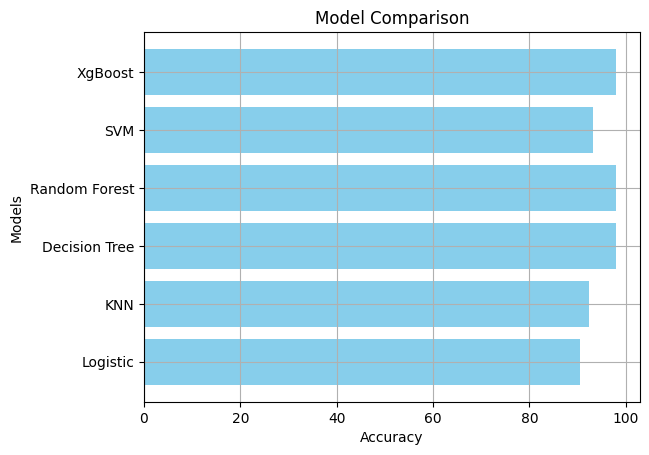

In [87]:
plt.barh(models, accuracy , color = "skyblue")
plt.xlabel("Accuracy")
plt.ylabel("Models")
plt.grid(True)
plt.title("Model Comparison")
plt.show()

In [88]:
import joblib

In [89]:
joblib.dump(rf , "loan_prediction_pipeline.pkl")
joblib.dump(le_status, "status_encoder.pkl")

['status_encoder.pkl']

# Gradeint Boosting

In [90]:
from sklearn.ensemble import GradientBoostingClassifier

In [91]:
gb = GradientBoostingClassifier()
gb.fit(x_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [92]:
y_p = gb.predict(x_test)
print("Classification Report : " , classification_report(y_test,y_p))

Classification Report :                precision    recall  f1-score   support

           0       0.97      0.99      0.98       536
           1       0.98      0.95      0.96       318

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [93]:
gbAcc = accuracy_score(y_p,y_test)
print("gb Accuracy : {:.2f}%".format(gbAcc*100))

gb Accuracy : 97.31%


In [94]:
accuracy = accuracy_score(y_test, y_p)

# Precision
precision = precision_score(y_test, y_p)

# Recall
recall = recall_score(y_test, y_p)

# F1 Score
f1 = f1_score(y_test, y_p)

print("Accuracy:", accuracy*100)
print("Precision:", precision*100)
print("Recall:", recall*100)
print("F1 Score:", f1*100)

Accuracy: 97.30679156908664
Precision: 97.73462783171522
Recall: 94.9685534591195
F1 Score: 96.33173843700159


# ADA Boost

In [95]:
from sklearn.ensemble import AdaBoostClassifier

In [96]:
ada = AdaBoostClassifier()
ada.fit(x_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [97]:
predict = ada.predict(x_test)
print("Classification Report : " , classification_report(y_test,predict))

Classification Report :                precision    recall  f1-score   support

           0       0.98      0.97      0.97       536
           1       0.94      0.97      0.96       318

    accuracy                           0.97       854
   macro avg       0.96      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [98]:
adaAcc = accuracy_score(y_p,y_test)
print("ada Accuracy : {:.2f}%".format(adaAcc*100))

ada Accuracy : 97.31%


In [99]:
accuracy = accuracy_score(y_test, predict)

# Precision
precision = precision_score(y_test, predict)

# Recall
recall = recall_score(y_test, predict)

# F1 Score
f1 = f1_score(y_test, predict)

print("Accuracy:", accuracy*100)
print("Precision:", precision*100)
print("Recall:", recall*100)
print("F1 Score:", f1*100)

Accuracy: 96.72131147540983
Precision: 94.47852760736197
Recall: 96.85534591194968
F1 Score: 95.65217391304348


# Stacking Ensemble Learning

In [100]:
from sklearn.ensemble import StackingClassifier

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
!pip install lightgbm
from lightgbm import LGBMClassifier

In [ ]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced')),
    ('xgb', XGBClassifier()),
    ('lgb', LGBMClassifier())
]

In [ ]:
stack = StackingClassifier(
    estimators = estimators,
    final_estimator = LogisticRegression()
)

In [ ]:
stack.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 1295, number of negative: 2120
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1443
[LightGBM] [Info] Number of data points in the train set: 3415, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.379209 -> initscore=-0.492905
[LightGBM] [Info] Start training from score -0.492905
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

StackingClassifier(estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=15)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_weights=Non...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('lgb', LGBMClassifier())],
                   final_estimator=LogisticRegression())

In [ ]:
stack_prediction = stack.predict(x_test)
print("Classification Report : " , classification_report(y_test,stack_prediction))

Classification Report :                precision    recall  f1-score   support

           0       0.99      0.99      0.99       536
           1       0.98      0.97      0.98       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [ ]:
stackAcc = accuracy_score(stack_prediction,y_test)
print("stack Accuracy : {:.2f}%".format(stackAcc*100))

stack Accuracy : 98.36%


In [ ]:
accuracy = accuracy_score(y_test, stack_prediction)

# Precision
precision = precision_score(y_test, stack_prediction)

# Recall
recall = recall_score(y_test, stack_prediction)

# F1 Score
f1 = f1_score(y_test, stack_prediction)

print("Accuracy:", accuracy*100)
print("Precision:", precision*100)
print("Recall:", recall*100)
print("F1 Score:", f1*100)

Accuracy: 98.36065573770492
Precision: 98.10126582278481
Recall: 97.48427672955975
F1 Score: 97.79179810725552


In [ ]:
pd.DataFrame({"Model"  : ['Logistic Regression' , 'k Neighbors Classifier' , 'Decision Tree Classifier' , 'Random Forest' , 'SVM Classifier' , 'XgBoost Classifier','Gradeint Boosting','ADA Boost','LightGBM','CatBoost','StackingClassifier'] ,
              "Accuracy" : [lrAcc*100 , KnnAcc*100 , DtAcc*100  , RfAcc*100 , SvAcc*100 , XgBAcc*100, gbAcc*100, adaAcc*100, lgbmAcc*100, catAcc*100, stackAcc*100]}).sort_values(by = "Accuracy" , ascending=False)

,Model,Accuracy
10,StackingClassifier,98.360656
2,Decision Tree Classifier,98.126464
3,Random Forest,98.009368
5,XgBoost Classifier,97.892272
7,ADA Boost,97.306792
8,LightGBM,97.306792
6,Gradeint Boosting,97.306792
9,CatBoost,97.306792
4,SVM Classifier,93.091335
1,k Neighbors Classifier,92.388759


# Voting Ensemble

In [ ]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced')),
        ('xgb', XGBClassifier()),
        ('gb', GradientBoostingClassifier())
    ],
    voting='soft'
)

voting.fit(x_train, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=15)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None,...
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('gb', GradientBoostingClassifier())],
                 voting='soft')

In [ ]:
voting_prediction = voting.predict(x_test)
print("Classification Report : " , classification_report(y_test,voting_prediction))

Classification Report :                precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [ ]:
voteAcc = accuracy_score(voting_prediction,y_test)
print("stack Accuracy : {:.2f}%".format(voteAcc*100))

stack Accuracy : 98.01%


In [ ]:
model = pd.DataFrame({"Model"  : ['Logistic Regression' , 'k Neighbors Classifier' , 'Decision Tree Classifier' , 'Random Forest' , 'SVM Classifier' , 'XgBoost Classifier','Gradeint Boosting','ADA Boost','LightGBM','CatBoost','StackingClassifier','VotingClassifer'] ,
              "Accuracy" : [lrAcc*100 , KnnAcc*100 , DtAcc*100  , RfAcc*100 , SvAcc*100 , XgBAcc*100, gbAcc*100, adaAcc*100, lgbmAcc*100, catAcc*100, stackAcc*100, voteAcc*100]}).sort_values(by = "Accuracy" , ascending=False)

In [ ]:
model

,Model,Accuracy
10,StackingClassifier,98.360656
2,Decision Tree Classifier,98.126464
11,VotingClassifer,98.009368
3,Random Forest,98.009368
5,XgBoost Classifier,97.892272
7,ADA Boost,97.306792
9,CatBoost,97.306792
6,Gradeint Boosting,97.306792
8,LightGBM,97.306792
4,SVM Classifier,93.091335


In [ ]:
models = pd.DataFrame({"Model"  : ['Logistic Regression' , 'k Neighbors Classifier' , 'Decision Tree Classifier' , 'Random Forest' , 'SVM Classifier' , 'XgBoost Classifier','StackingClassifier'] ,
              "Accuracy" : [lrAcc*100 , KnnAcc*100 , DtAcc*100  , RfAcc*100 , SvAcc*100 , XgBAcc*100,stackAcc*100]}).sort_values(by = "Accuracy" , ascending=False)

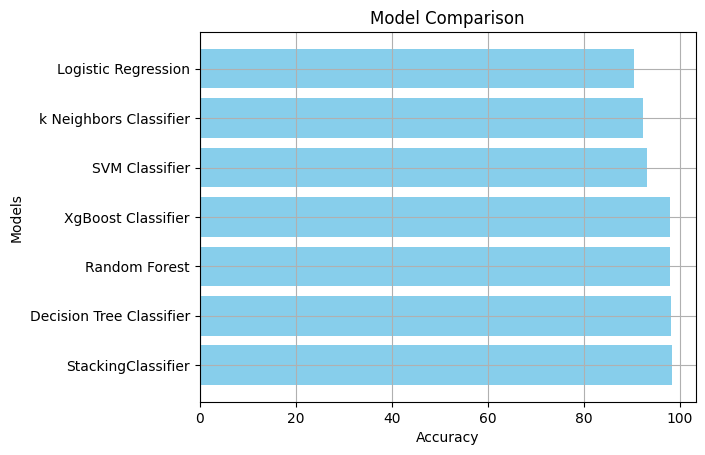

In [ ]:
plt.barh(models['Model'], models['Accuracy'] , color = "skyblue")
plt.xlabel("Accuracy")
plt.ylabel("Models")
plt.grid(True)
plt.title("Model Comparison")
plt.show()